## Step 1 — Install & Import

In [76]:
!pip install pandas matplotlib -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


## Step 2 — Load Both Modality Outputs

In [78]:
# ── PDF Output ────────────────────────────────────────────────────────────────
if os.path.exists('pdf_output.csv'):
    df_pdf = pd.read_csv('pdf_output.csv')
    print(f' pdf_output.csv loaded: {df_pdf.shape}')
else:
    print('pdf_output.csv not found — using sample data')
    df_pdf = pd.DataFrame([
        {'Report_ID': 'RPT_001', 'Incident_Type': 'Training / Equipment', 'Date': '2015-04-10',
         'Location': 'Arkansas', 'Officer': 'Officer Smith', 'Organization': 'Arkansas PD',
         'Summary': 'Request for tactical training equipment submitted by department.'},
        {'Report_ID': 'RPT_002', 'Incident_Type': 'General Report',       'Date': '2015-06-22',
         'Location': 'Little Rock', 'Officer': 'Unknown', 'Organization': 'State Police',
         'Summary': 'Annual review documentation submitted for 1033 program compliance.'},
        {'Report_ID': 'RPT_003', 'Incident_Type': 'Training / Equipment', 'Date': 'Unknown',
         'Location': 'Unknown', 'Officer': 'Officer Davis', 'Organization': 'Unknown',
         'Summary': 'Equipment transfer request: body armor and communication devices.'}
    ])

print(df_pdf.head())

# ── Text Output ───────────────────────────────────────────────────────────────
if os.path.exists('text_output.csv'):
    df_text = pd.read_csv('text_output.csv')
    print(f'\ntext_output.csv loaded: {df_text.shape}')
else:
    print('\ntext_output.csv not found — using sample data')
    df_text = pd.DataFrame([
        {'Text_ID': 'TXT_001', 'Source': 'CrimeReport', 'Raw_Text': 'Robbery on Oak Street Chicago.',
         'Sentiment': 'NEGATIVE', 'Sentiment_Score': 0.97, 'Entities_People': 'None',
         'Entities_Locations': 'Oak Street, Chicago', 'Entities_Orgs': 'None', 'Topic': 'Theft / Robbery', 'Severity': 'High'},
        {'Text_ID': 'TXT_002', 'Source': 'CrimeReport', 'Raw_Text': 'Fire broke out at Oak Ave warehouse.',
         'Sentiment': 'NEGATIVE', 'Sentiment_Score': 0.89, 'Entities_People': 'None',
         'Entities_Locations': 'Oak Ave', 'Entities_Orgs': 'None', 'Topic': 'Fire', 'Severity': 'High'},
        {'Text_ID': 'TXT_003', 'Source': 'CrimeReport', 'Raw_Text': 'Vehicle collision at Highway 59.',
         'Sentiment': 'NEGATIVE', 'Sentiment_Score': 0.91, 'Entities_People': 'None',
         'Entities_Locations': 'Highway 59', 'Entities_Orgs': 'None', 'Topic': 'Traffic Accident', 'Severity': 'Medium'},
        {'Text_ID': 'TXT_004', 'Source': 'CrimeReport', 'Raw_Text': 'Drug possession arrest on Shepherd Drive.',
         'Sentiment': 'NEGATIVE', 'Sentiment_Score': 0.85, 'Entities_People': 'John Doe',
         'Entities_Locations': 'Shepherd Drive', 'Entities_Orgs': 'None', 'Topic': 'Drug Offense', 'Severity': 'Medium'},
        {'Text_ID': 'TXT_005', 'Source': 'CrimeReport', 'Raw_Text': 'Gang shooting near Sunnyside. Two victims hospitalized.',
         'Sentiment': 'NEGATIVE', 'Sentiment_Score': 0.99, 'Entities_People': 'None',
         'Entities_Locations': 'Sunnyside', 'Entities_Orgs': 'Ben Taub Hospital', 'Topic': 'Assault / Violence', 'Severity': 'High'}
    ])

print(df_text.head())

 pdf_output.csv loaded: (14, 7)
  Report_ID         Incident_Type              Date Location        Officer  \
0   RPT_001  Training / Equipment  January 19, 2015  Unknown       McMillen   
1   RPT_002  Training / Equipment   June 30th, 2014  Unknown       Training   
2   RPT_003  Training / Equipment           Unknown  Unknown        Unknown   
3   RPT_004  Training / Equipment           Unknown  Unknown  Eric Wacaster   
4   RPT_005  Training / Equipment           Unknown   Rostan  Eric Wacaster   

                                        Organization  \
0                 Fort Smith Police Department\nDate   
1  Cpl Monty McMillen\n5.0 Hours Swat Team Operat...   
2  Evacuations / Emergency Situations\nRequired T...   
3                      Hot Springs Police Department   
4                      Hot Springs Police Department   

                                             Summary  
0  To: Whom it may Concern From: Fort Smith Polic...  
1  COURSE: LESSON TITLE: CLEET Continuing Educ

## Step 3 — Standardize to Unified Schema

In [80]:
def severity_from_topic(incident_type):
    """Assign severity for PDF records based on incident type."""
    high = ['Assault', 'Fire', 'Missing Person', 'Shooting']
    med  = ['Theft', 'Traffic Accident', 'Drug Offense', 'Burglary']
    t = str(incident_type)
    if any(h in t for h in high):
        return 'High'
    elif any(m in t for m in med):
        return 'Medium'
    else:
        return 'Low'


# ── Normalize PDF records ─────────────────────────────────────────────────────
pdf_unified = pd.DataFrame({
    'Incident_ID':    [f'INC_{i+1:03d}' for i in range(len(df_pdf))],
    'Source':         'PDF Document',
    'Event':          df_pdf.get('Incident_Type', 'Unknown'),
    'Location':       df_pdf.get('Location',      'Unknown'),
    'Time':           df_pdf.get('Date',           'Unknown'),
    'Officer':        df_pdf.get('Officer',        'Unknown'),
    'Organization':   df_pdf.get('Organization',   'Unknown'),
    'Sentiment':      'N/A',
    'Entities':       df_pdf.get('Officer',        'Unknown'),
    'Summary':        df_pdf.get('Summary',        ''),
    'Severity':       df_pdf.get('Incident_Type',  'Unknown').apply(severity_from_topic)
})

print(f'PDF records normalized: {len(pdf_unified)}')


# ── Normalize Text records ────────────────────────────────────────────────────
offset = len(df_pdf)

text_unified = pd.DataFrame({
    'Incident_ID':    [f'INC_{offset+i+1:03d}' for i in range(len(df_text))],
    'Source':         'Text / Social Media',
    'Event':          df_text.get('Topic',               'Unknown'),
    'Location':       df_text.get('Entities_Locations',  'Unknown'),
    'Time':           'Unknown',
    'Officer':        'N/A',
    'Organization':   df_text.get('Entities_Orgs',       'N/A'),
    'Sentiment':      df_text.get('Sentiment',           'Unknown'),
    'Entities':       df_text.get('Entities_People',     'None'),
    'Summary':        df_text.get('Raw_Text',            ''),
    'Severity':       df_text.get('Severity',            'Low')
})

print(f'Text records normalized: {len(text_unified)}')

PDF records normalized: 14
Text records normalized: 20


## Step 4 — Merge into Master Dataset

In [82]:
master_df = pd.concat([pdf_unified, text_unified], ignore_index=True)

# Fill any remaining NaN values
master_df.fillna('Unknown', inplace=True)

# Clean up whitespace
for col in master_df.select_dtypes(include='object').columns:
    master_df[col] = master_df[col].astype(str).str.strip()

# Ensure severity is consistent
master_df['Severity'] = master_df['Severity'].replace({
    'nan': 'Low', '': 'Low', 'Unknown': 'Low'
})

print(f'Master dataset created')
print(f'   Total incidents : {len(master_df)}')
print(f'   Columns         : {list(master_df.columns)}')
master_df

Master dataset created
   Total incidents : 34
   Columns         : ['Incident_ID', 'Source', 'Event', 'Location', 'Time', 'Officer', 'Organization', 'Sentiment', 'Entities', 'Summary', 'Severity']


,Incident_ID,Source,Event,Location,Time,Officer,Organization,Sentiment,Entities,Summary,Severity
0,INC_001,PDF Document,Training / Equipment,Unknown,"January 19, 2015",McMillen,Fort Smith Police Department\nDate,N/A,McMillen,To: Whom it may Concern From: Fort Smith Polic...,Low
1,INC_002,PDF Document,Training / Equipment,Unknown,"June 30th, 2014",Training,Cpl Monty McMillen\n5.0 Hours Swat Team Operat...,N/A,Training,COURSE: LESSON TITLE: CLEET Continuing Educati...,Low
2,INC_003,PDF Document,Training / Equipment,Unknown,Unknown,Unknown,Evacuations / Emergency Situations\nRequired T...,N/A,Unknown,Evacuations / Emergency Situations Required Tr...,Low
3,INC_004,PDF Document,Training / Equipment,Unknown,Unknown,Eric Wacaster,Hot Springs Police Department,N/A,Eric Wacaster,Hot Springs Police Department S.W.A.T. Trainin...,Low
4,INC_005,PDF Document,Training / Equipment,Rostan,Unknown,Eric Wacaster,Hot Springs Police Department,N/A,Eric Wacaster,Hot Springs Police Department S.W.A.T. Trainin...,Low
5,INC_006,PDF Document,Training / Equipment,Unknown,Unknown,Shut Down,Hot Springs Police Department,N/A,Shut Down,Hot Springs Police Department S.W.A.T. Trainin...,Low
6,INC_007,PDF Document,Training / Equipment,Unknown,Unknown,Zac Rostan,Unknown,N/A,Zac Rostan,References None Training Aids MRAP Coordinatio...,Low
7,INC_008,PDF Document,Training / Equipment,the United States\nGovernment,"January 14, 2015",Brett Hibbs\nDate,the Jacksonville AR Police Department,N/A,Brett Hibbs\nDate,To: Whom it may Concern From: Lt. Brett Hibbs ...,Low
8,INC_009,PDF Document,Training / Equipment,Unknown,Unknown,Driver Training Mine Resistant Ambush,Operations of the Mine Resistant Ambush Protec...,N/A,Driver Training Mine Resistant Ambush,COURSE: LESSON TITLE: MRAP Driver Training Min...,Low
9,INC_010,PDF Document,Training / Equipment,Unknown,"January 13, 2015",Vehicle,Vehicle\nStandard Operating Procedure,N/A,Vehicle,Mine Resistant Ambush Protected (MRAP) Vehicle...,Low


## Step 5 — Save Master CSV

In [84]:
master_df.to_csv('master_incident_report.csv', index=False)
print('Saved: master_incident_report.csv')

# Preview final structure matching the assignment's expected output
preview_cols = ['Incident_ID', 'Source', 'Event', 'Location', 'Time', 'Severity']
print('\n--- Final Structured Output (Assignment Format) ---')
master_df[preview_cols]

Saved: master_incident_report.csv

--- Final Structured Output (Assignment Format) ---


,Incident_ID,Source,Event,Location,Time,Severity
0,INC_001,PDF Document,Training / Equipment,Unknown,"January 19, 2015",Low
1,INC_002,PDF Document,Training / Equipment,Unknown,"June 30th, 2014",Low
2,INC_003,PDF Document,Training / Equipment,Unknown,Unknown,Low
3,INC_004,PDF Document,Training / Equipment,Unknown,Unknown,Low
4,INC_005,PDF Document,Training / Equipment,Rostan,Unknown,Low
5,INC_006,PDF Document,Training / Equipment,Unknown,Unknown,Low
6,INC_007,PDF Document,Training / Equipment,Unknown,Unknown,Low
7,INC_008,PDF Document,Training / Equipment,the United States\nGovernment,"January 14, 2015",Low
8,INC_009,PDF Document,Training / Equipment,Unknown,Unknown,Low
9,INC_010,PDF Document,Training / Equipment,Unknown,"January 13, 2015",Low


## Step 6 — Dashboard: Summary Stats

In [86]:
print('=' * 45)
print('     MULTIMODAL INCIDENT REPORT DASHBOARD')
print('=' * 45)
print(f'  Total incidents analyzed : {len(master_df)}')
print(f'  Data sources             : {master_df["Source"].nunique()}')
print(f'  High severity incidents  : {(master_df["Severity"] == "High").sum()}')
print(f'  Medium severity          : {(master_df["Severity"] == "Medium").sum()}')
print(f'  Low severity             : {(master_df["Severity"] == "Low").sum()}')
print()
print('  Breakdown by Source:')
for source, count in master_df['Source'].value_counts().items():
    print(f'    {source:25s}: {count} incidents')
print()
print('  Breakdown by Event Type:')
for event, count in master_df['Event'].value_counts().head(8).items():
    print(f'    {str(event)[:30]:30s}: {count}')
print('=' * 45)

     MULTIMODAL INCIDENT REPORT DASHBOARD
  Total incidents analyzed : 34
  Data sources             : 2
  High severity incidents  : 19
  Medium severity          : 0
  Low severity             : 15

  Breakdown by Source:
    Text / Social Media      : 20 incidents
    PDF Document             : 14 incidents

  Breakdown by Event Type:
    General Incident              : 15
    Training / Equipment          : 14
    Assault / Violence            : 4
    Theft / Robbery               : 1


## Step 7 — Dashboard: Visualizations

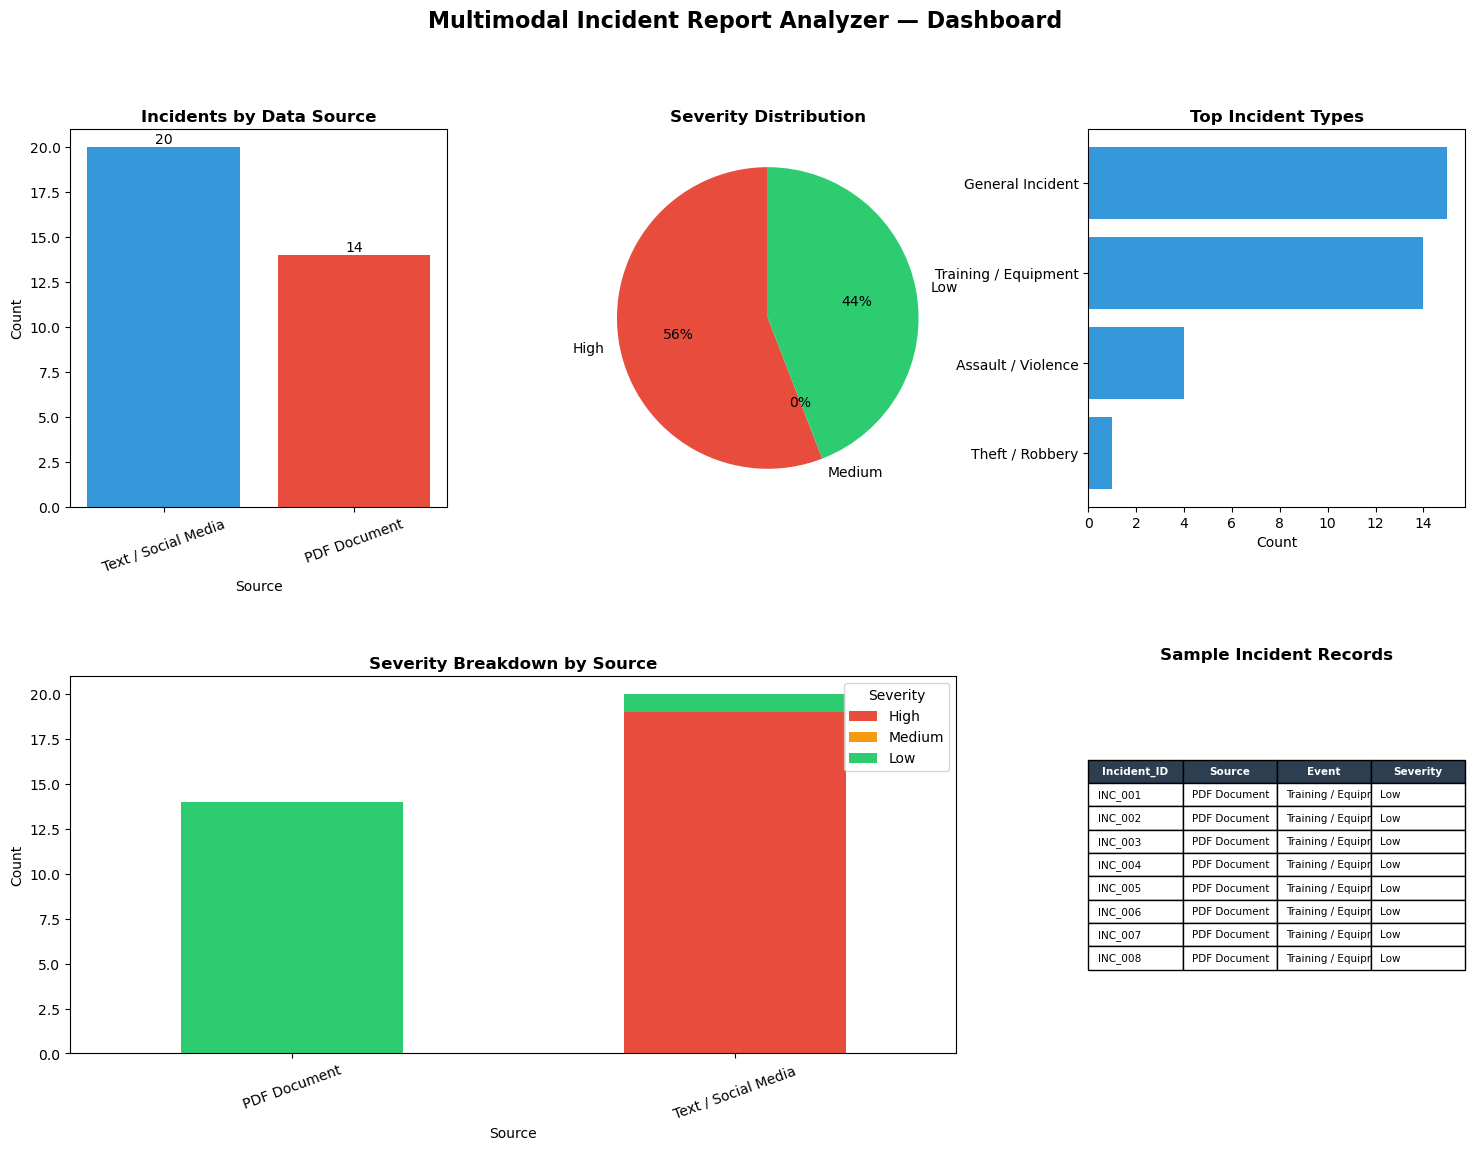

Dashboard saved: dashboard.png


In [88]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Multimodal Incident Report Analyzer — Dashboard', fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Incidents by Source ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
source_counts = master_df['Source'].value_counts()
bars = ax1.bar(source_counts.index, source_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
ax1.set_title('Incidents by Data Source', fontweight='bold')
ax1.set_xlabel('Source')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=20)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# ── 2. Severity Distribution ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
severity_order  = ['High', 'Medium', 'Low']
severity_colors = ['#e74c3c', '#f39c12', '#2ecc71']
severity_counts = master_df['Severity'].value_counts().reindex(severity_order, fill_value=0)
wedges, texts, autotexts = ax2.pie(
    severity_counts.values,
    labels=severity_counts.index,
    colors=severity_colors,
    autopct='%1.0f%%',
    startangle=90
)
ax2.set_title('Severity Distribution', fontweight='bold')

# ── 3. Top Event Types ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
event_counts = master_df['Event'].value_counts().head(7)
ax3.barh(event_counts.index[::-1], event_counts.values[::-1], color='#3498db')
ax3.set_title('Top Incident Types', fontweight='bold')
ax3.set_xlabel('Count')

# ── 4. Severity by Source (Stacked Bar) ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
pivot = master_df.groupby(['Source', 'Severity']).size().unstack(fill_value=0)
for col in ['High', 'Medium', 'Low']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot[['High', 'Medium', 'Low']].plot(
    kind='bar', stacked=True, ax=ax4,
    color=['#e74c3c', '#f39c12', '#2ecc71']
)
ax4.set_title('Severity Breakdown by Source', fontweight='bold')
ax4.set_xlabel('Source')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=20)
ax4.legend(title='Severity', loc='upper right')

# ── 5. Incidents Table (text plot) ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
table_data = master_df[['Incident_ID', 'Source', 'Event', 'Severity']].head(8)
table = ax5.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1, 1.4)
# Color header row
for j in range(len(table_data.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax5.set_title('Sample Incident Records', fontweight='bold', pad=12)

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: dashboard.png')

## Step 8 — Filterable Incident Query System

In [90]:
def query_incidents(severity=None, source=None, event_keyword=None):
    """
    Filter the master incident dataset.
    
    Parameters:
      severity      : 'High', 'Medium', or 'Low'
      source        : 'PDF Document' or 'Text / Social Media'
      event_keyword : any keyword to search in Event column
    """
    df = master_df.copy()

    if severity:
        df = df[df['Severity'].str.lower() == severity.lower()]
    if source:
        df = df[df['Source'].str.lower().str.contains(source.lower())]
    if event_keyword:
        df = df[df['Event'].str.lower().str.contains(event_keyword.lower())]

    print(f'\nQuery Results: {len(df)} incidents found')
    if len(df) == 0:
        print('   No matching incidents.')
    else:
        display_cols = ['Incident_ID', 'Source', 'Event', 'Location', 'Time', 'Severity']
        print(df[display_cols].to_string(index=False))
    return df


# ── Example queries ───────────────────────────────────────────────────────────
print('Example 1 — All HIGH severity incidents:')
query_incidents(severity='High')

Example 1 — All HIGH severity incidents:

Query Results: 19 incidents found
Incident_ID              Source              Event Location    Time Severity
    INC_015 Text / Social Media Assault / Violence  Unknown Unknown     High
    INC_016 Text / Social Media Assault / Violence  Unknown Unknown     High
    INC_017 Text / Social Media   General Incident  Chicago Unknown     High
    INC_018 Text / Social Media   General Incident  Unknown Unknown     High
    INC_019 Text / Social Media   General Incident  Unknown Unknown     High
    INC_020 Text / Social Media   General Incident  Unknown Unknown     High
    INC_021 Text / Social Media    Theft / Robbery  Unknown Unknown     High
    INC_022 Text / Social Media   General Incident Pakistan Unknown     High
    INC_023 Text / Social Media   General Incident  Unknown Unknown     High
    INC_025 Text / Social Media   General Incident  Unknown Unknown     High
    INC_026 Text / Social Media   General Incident  Unknown Unknown     High


,Incident_ID,Source,Event,Location,Time,Officer,Organization,Sentiment,Entities,Summary,Severity
14,INC_015,Text / Social Media,Assault / Violence,Unknown,Unknown,N/A,Unknown,NEGATIVE,Unknown,Active crime scene on I-59/20 near Jeff/Tusc C...,High
15,INC_016,Text / Social Media,Assault / Violence,Unknown,Unknown,N/A,Word Tabernacle Church,NEGATIVE,Unknown,Police have arrested a suspect in the Monday s...,High
16,INC_017,Text / Social Media,General Incident,Chicago,Unknown,N/A,Unknown,NEGATIVE,Unknown,Lawsuit alleges Chicago Police strip-searched ...,High
17,INC_018,Text / Social Media,General Incident,Unknown,Unknown,N/A,New NRA Advice,NEGATIVE,Unknown,New NRA Advice: Don't Cooperate With Police If...,High
18,INC_019,Text / Social Media,General Incident,Unknown,Unknown,N/A,FGM,NEGATIVE,Unknown,"Police failing to stamp out ‘honour crimes’, f...",High
19,INC_020,Text / Social Media,General Incident,Unknown,Unknown,N/A,Unknown,NEGATIVE,Unknown,Today's front page: \nPolice failing to stamp ...,High
20,INC_021,Text / Social Media,Theft / Robbery,Unknown,Unknown,N/A,Town of Tonawanda Police Search for Bank Robbe...,NEGATIVE,Unknown,Town of Tonawanda Police Search for Bank Robbe...,High
21,INC_022,Text / Social Media,General Incident,Pakistan,Unknown,N/A,Unknown,NEGATIVE,Unknown,"Due to lack of police protection, #Christians ...",High
22,INC_023,Text / Social Media,General Incident,Unknown,Unknown,N/A,Crime Scene,NEGATIVE,Unknown,New #NRA Advice: Don't Cooperate With Police I...,High
24,INC_025,Text / Social Media,General Incident,Unknown,Unknown,N/A,Unknown,NEGATIVE,Redbridge,Police swoop on the homeless taking sleeping b...,High


In [91]:
print('Example 2 — All incidents from PDF source:')
query_incidents(source='PDF')

Example 2 — All incidents from PDF source:

Query Results: 14 incidents found
Incident_ID       Source                Event                       Location             Time Severity
    INC_001 PDF Document Training / Equipment                        Unknown January 19, 2015      Low
    INC_002 PDF Document Training / Equipment                        Unknown  June 30th, 2014      Low
    INC_003 PDF Document Training / Equipment                        Unknown          Unknown      Low
    INC_004 PDF Document Training / Equipment                        Unknown          Unknown      Low
    INC_005 PDF Document Training / Equipment                         Rostan          Unknown      Low
    INC_006 PDF Document Training / Equipment                        Unknown          Unknown      Low
    INC_007 PDF Document Training / Equipment                        Unknown          Unknown      Low
    INC_008 PDF Document Training / Equipment  the United States\nGovernment January 14, 2015     

,Incident_ID,Source,Event,Location,Time,Officer,Organization,Sentiment,Entities,Summary,Severity
0,INC_001,PDF Document,Training / Equipment,Unknown,"January 19, 2015",McMillen,Fort Smith Police Department\nDate,N/A,McMillen,To: Whom it may Concern From: Fort Smith Polic...,Low
1,INC_002,PDF Document,Training / Equipment,Unknown,"June 30th, 2014",Training,Cpl Monty McMillen\n5.0 Hours Swat Team Operat...,N/A,Training,COURSE: LESSON TITLE: CLEET Continuing Educati...,Low
2,INC_003,PDF Document,Training / Equipment,Unknown,Unknown,Unknown,Evacuations / Emergency Situations\nRequired T...,N/A,Unknown,Evacuations / Emergency Situations Required Tr...,Low
3,INC_004,PDF Document,Training / Equipment,Unknown,Unknown,Eric Wacaster,Hot Springs Police Department,N/A,Eric Wacaster,Hot Springs Police Department S.W.A.T. Trainin...,Low
4,INC_005,PDF Document,Training / Equipment,Rostan,Unknown,Eric Wacaster,Hot Springs Police Department,N/A,Eric Wacaster,Hot Springs Police Department S.W.A.T. Trainin...,Low
5,INC_006,PDF Document,Training / Equipment,Unknown,Unknown,Shut Down,Hot Springs Police Department,N/A,Shut Down,Hot Springs Police Department S.W.A.T. Trainin...,Low
6,INC_007,PDF Document,Training / Equipment,Unknown,Unknown,Zac Rostan,Unknown,N/A,Zac Rostan,References None Training Aids MRAP Coordinatio...,Low
7,INC_008,PDF Document,Training / Equipment,the United States\nGovernment,"January 14, 2015",Brett Hibbs\nDate,the Jacksonville AR Police Department,N/A,Brett Hibbs\nDate,To: Whom it may Concern From: Lt. Brett Hibbs ...,Low
8,INC_009,PDF Document,Training / Equipment,Unknown,Unknown,Driver Training Mine Resistant Ambush,Operations of the Mine Resistant Ambush Protec...,N/A,Driver Training Mine Resistant Ambush,COURSE: LESSON TITLE: MRAP Driver Training Min...,Low
9,INC_010,PDF Document,Training / Equipment,Unknown,"January 13, 2015",Vehicle,Vehicle\nStandard Operating Procedure,N/A,Vehicle,Mine Resistant Ambush Protected (MRAP) Vehicle...,Low


In [92]:
print('Example 3 — Search for "Fire" incidents:')
query_incidents(event_keyword='fire')

Example 3 — Search for "Fire" incidents:

Query Results: 0 incidents found
   No matching incidents.


,Incident_ID,Source,Event,Location,Time,Officer,Organization,Sentiment,Entities,Summary,Severity


In [93]:
print('Example 4 — HIGH severity from Text source:')
query_incidents(severity='High', source='Text')

Example 4 — HIGH severity from Text source:

Query Results: 19 incidents found
Incident_ID              Source              Event Location    Time Severity
    INC_015 Text / Social Media Assault / Violence  Unknown Unknown     High
    INC_016 Text / Social Media Assault / Violence  Unknown Unknown     High
    INC_017 Text / Social Media   General Incident  Chicago Unknown     High
    INC_018 Text / Social Media   General Incident  Unknown Unknown     High
    INC_019 Text / Social Media   General Incident  Unknown Unknown     High
    INC_020 Text / Social Media   General Incident  Unknown Unknown     High
    INC_021 Text / Social Media    Theft / Robbery  Unknown Unknown     High
    INC_022 Text / Social Media   General Incident Pakistan Unknown     High
    INC_023 Text / Social Media   General Incident  Unknown Unknown     High
    INC_025 Text / Social Media   General Incident  Unknown Unknown     High
    INC_026 Text / Social Media   General Incident  Unknown Unknown     Hi

,Incident_ID,Source,Event,Location,Time,Officer,Organization,Sentiment,Entities,Summary,Severity
14,INC_015,Text / Social Media,Assault / Violence,Unknown,Unknown,N/A,Unknown,NEGATIVE,Unknown,Active crime scene on I-59/20 near Jeff/Tusc C...,High
15,INC_016,Text / Social Media,Assault / Violence,Unknown,Unknown,N/A,Word Tabernacle Church,NEGATIVE,Unknown,Police have arrested a suspect in the Monday s...,High
16,INC_017,Text / Social Media,General Incident,Chicago,Unknown,N/A,Unknown,NEGATIVE,Unknown,Lawsuit alleges Chicago Police strip-searched ...,High
17,INC_018,Text / Social Media,General Incident,Unknown,Unknown,N/A,New NRA Advice,NEGATIVE,Unknown,New NRA Advice: Don't Cooperate With Police If...,High
18,INC_019,Text / Social Media,General Incident,Unknown,Unknown,N/A,FGM,NEGATIVE,Unknown,"Police failing to stamp out ‘honour crimes’, f...",High
19,INC_020,Text / Social Media,General Incident,Unknown,Unknown,N/A,Unknown,NEGATIVE,Unknown,Today's front page: \nPolice failing to stamp ...,High
20,INC_021,Text / Social Media,Theft / Robbery,Unknown,Unknown,N/A,Town of Tonawanda Police Search for Bank Robbe...,NEGATIVE,Unknown,Town of Tonawanda Police Search for Bank Robbe...,High
21,INC_022,Text / Social Media,General Incident,Pakistan,Unknown,N/A,Unknown,NEGATIVE,Unknown,"Due to lack of police protection, #Christians ...",High
22,INC_023,Text / Social Media,General Incident,Unknown,Unknown,N/A,Crime Scene,NEGATIVE,Unknown,New #NRA Advice: Don't Cooperate With Police I...,High
24,INC_025,Text / Social Media,General Incident,Unknown,Unknown,N/A,Unknown,NEGATIVE,Redbridge,Police swoop on the homeless taking sleeping b...,High


## Step 9 — Auto-generate Incident Summary (LLM Bonus)

In [95]:
# Generates a human-readable summary from the master dataset without an LLM
# (pure Python — always works)

high_count   = (master_df['Severity'] == 'High').sum()
med_count    = (master_df['Severity'] == 'Medium').sum()
low_count    = (master_df['Severity'] == 'Low').sum()
top_event    = master_df['Event'].value_counts().idxmax()
top_location = master_df['Location'].replace('Unknown', pd.NA).dropna()
top_location = top_location.value_counts().idxmax() if len(top_location) > 0 else 'Unknown'

summary = f"""

          AUTOMATED INCIDENT REPORT SUMMARY              

  Total incidents analyzed : {len(master_df):<5}                     
  Data sources integrated  : {master_df['Source'].nunique():<5}                     
                                                          
  Severity Breakdown:                                     
   High   : {high_count:<5}                                   
   Medium : {med_count:<5}                                   
   Low    : {low_count:<5}                                   
                                                         
  Most Common Incident : {str(top_event)[:32]:<32}  
  Most Active Location : {str(top_location)[:32]:<32} 
"""

print(summary)



          AUTOMATED INCIDENT REPORT SUMMARY              

  Total incidents analyzed : 34                        
  Data sources integrated  : 2                         
                                                          
  Severity Breakdown:                                     
   High   : 19                                      
   Medium : 0                                       
   Low    : 15                                      
                                                         
  Most Common Incident : General Incident                  
  Most Active Location : Delhi                            



## Step 10 — Final File Checklist

In [97]:
files_to_check = [
    ('pdf_output.csv',              'PDF modality structured output'),
    ('text_output.csv',             'Text modality structured output'),
    ('master_incident_report.csv',  'Final merged dataset'),
    ('dashboard.png',               'Dashboard visualization'),
    ('pdf_chart.png',               'PDF modality chart'),
    ('text_charts.png',             'Text modality charts'),
]

print('=== Submission File Checklist ===')
all_ok = True
for filename, description in files_to_check:
    exists = os.path.exists(filename)
    status = '' if exists else 'MISSING'
    if not exists:
        all_ok = False
    print(f'  {status}  {filename:40s}  ({description})')



=== Submission File Checklist ===
    pdf_output.csv                            (PDF modality structured output)
    text_output.csv                           (Text modality structured output)
    master_incident_report.csv                (Final merged dataset)
    dashboard.png                             (Dashboard visualization)
    pdf_chart.png                             (PDF modality chart)
    text_charts.png                           (Text modality charts)
